# Homework Chapters 12 and 13

Numbers correspond to homework problems from [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0FL7W88TM)

## Chapter 12

105. Using $\frac{df}{dt}  = \lim_{\Delta t \to 0} \frac{f(t+\Delta t)-f(t-\Delta t)}{2\Delta t}$,  show that the truncation error behaves like $\text{err}_t \approx C_t \Delta t^2$, where $C_t$ depends on $f(t)$. Use $f(t)=5e^{t}$ and find the value of $C_t$.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Solution 105
f = lambda t: 5*np.exp(t)
df = lambda t: 5*np.exp(t)
t0 = 0

dt_vec = 2.0**(-np.arange(1, 10,0.1))
exact_diff = df(t0)
err_c = []  # centered method error

for dt in dt_vec:
    Dc = (f(t0 + dt) - f(t0 - dt)) / (2*dt)
    err_c.append(abs(Dc - exact_diff))

In [12]:
def f_poly(t, a):
  return t**2*a

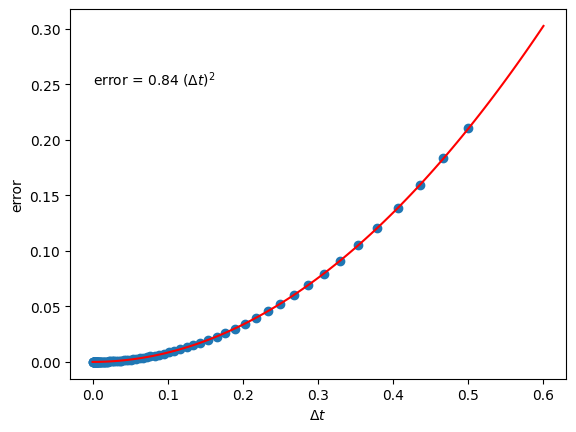

In [13]:
fig, ax = plt.subplots()
ax.scatter(dt_vec, err_c)
tv = np.linspace(0,0.6,100)
# later we will use fitting procedures, 
# but we can guess the solution in this case.
ax.plot(tv, f_poly(tv,0.84), color='red')
ax.text(0,0.25, r"error = 0.84 $(\Delta t)^2$")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel("error")
plt.show()

## Chapter 13

110. **(P)** A phone of mass $m = 0.2$ kg falls under gravity with a velocity-dependent drag force $F_d = \beta v^2$. Let $g = 9.8$ m/s<sup>2</sup> and $\beta = 0.7$.  **(a)**  Implement the forward Euler method to compute velocity $v(t)$ and momentum.  **(b)**  Plot $p(t)$ and find the terminal momentum.  **(c)**  What is the terminal velocity? Compare to $v_t = \sqrt{mg/\beta}$.  **(d)**  If dropped from 5000 m height, how long will it take to hit the ground?

In [14]:
# Solution 110 (part a)
N = 500
delta_time = 0.01
m, g, p0, beta = 2.,9.8,0.,0.7
t, p, v = [0.], [p0], [p0/m]
for n in range(N):
  t.append(t[n] + delta_time)
  Fn = -m * g + beta * (p[n]/m)**2
  pn = p[n] + Fn*delta_time
  p.append(pn)
  vn = pn/m
  v.append(vn)

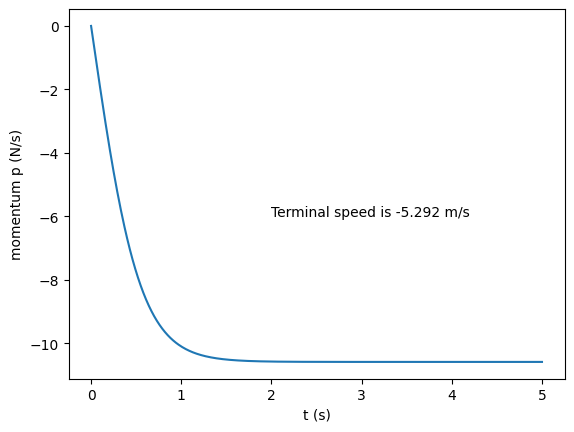

In [15]:
# Solution 110 (part b)
fig, ax = plt.subplots()
ax.plot(t, p)
ax.set_xlabel("t (s)"); ax.set_ylabel("momentum p (N/s)")
ax.text(2,-6,f"Terminal speed is {v[-1]:.3f} m/s")
plt.show()

In [16]:
# Solution 110 (part c)
print(f"Terminal speed from simulation is {v[-1]:.3f} m/s")
v_terminal = np.sqrt(m*g/beta)
print(f"Terminal speed from formula is {v_terminal:.3f} m/s")

Terminal speed from simulation is -5.292 m/s
Terminal speed from formula is 5.292 m/s


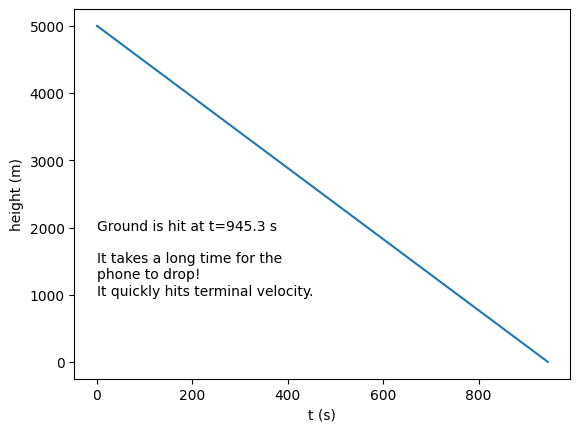

In [17]:
# Solution 110 (part d)

delta_time = 0.02
m, g, p0, beta = 2,9.8,0.,0.7
t, p, v = [0.], [p0], [p0/m]
x = [5000.]  # initial height
while x[-1] > 0:  # stop when it hits ground
  tn = t[-1] + delta_time
  t.append(tn)
  Fn = -m * g + beta * (p[-1]/m)**2
  pn = p[-1] + Fn*delta_time
  p.append(pn)
  vn = pn/m
  v.append(vn)
  # v = dx/dt
  # xn = xn-1 + vdt
  xn = x[-1] + v[-1]*delta_time
  x.append(xn)
  
fig, ax = plt.subplots()
ax.plot(t, x)
ax.text(0, 1000,f"Ground is hit at t={t[-1]:.1f} s\n\nIt takes a long time for the\nphone to drop!\nIt quickly hits terminal velocity.")
ax.set_xlabel("t (s)"); ax.set_ylabel("height (m)")

plt.show()

112. **(P)** Think of sedimentation of a plastic microbead in water dominated by *Stokes drag*.  A 2 $\mu$ m microbead experiences Stokes drag $F = 6\pi\eta rv$ in water ($\eta = 10^{-3}$ Pa $\cdot$ s).  **(a)**  Model its fall under gravity using the Euler-Cromer method.  **(b)**  Plot its terminal velocity.  **(c)**  Compare the viscous (low *Reynolds numbers*, $F = 6\pi\eta rv$) vs. inertial (high Reynolds numbers, $F = 0.5 \rho C_d A v^2$) regime for $>5$ different microbead radii. Use $C_d \approx 0.5$ for spheres, and $\rho$ is the density of water. The buoyancy force is $F_b = \rho_w V g$ and not negligble in a liquid. 

In [18]:
# Solution 112 part (a)

# set the parameters first
g = 9.81                       # m/s^2
eta = 1e-3                     # Pa*s  (dynamic viscosity of water, see above)
rho_w = 1000.                  # kg/m^3 (water density)
rho_p = 1200.                  # kg/m^3 (plastic microbead density, wide range, take average)
Cd = 0.5                       # sphere drag coefficient 
r0 = 2e-6/2                    # m (microbead radius)

Terminal speed is 4.36e-07 m/s.
It is reached after about 1 microsecond only.


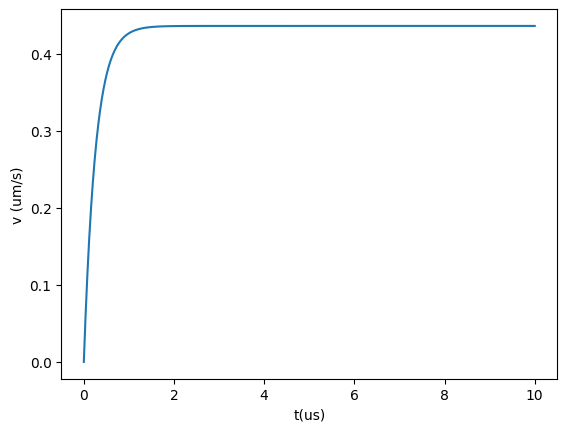

In [19]:
V0 = (4/3) * np.pi * r0**3
m0 = rho_p * V0
A0 = np.pi * r0**2
# net downward force from gravity + buoyancy
Fg0 = (rho_p - rho_w) * V0 * g

# (a) Euler–Cromer simulation with Stokes drag
# --------------------------------------------
# Time scale as to be very small for small particles
dt = 10e-9       # 10 ns (after trying different values)
tf = 1000 * dt   # final time
N = int(np.ceil(tf/dt)) + 1  # ladder problem, so +1

t = np.linspace(0, tf, N)
v = np.zeros(N)      # downward velocity (m/s)
y = np.zeros(N)      # downward position (m)

# Euler-Cromer to predict path
for n in range(N-1):
    F_drag = -6*np.pi*eta*r0 * v[n]  # drag is opposite to velocity direction
    F_net = Fg0 + F_drag  # mass down, drag up

    # Euler–Cromer update
    v[n+1] = v[n] + (F_net / m0) * dt
    y[n+1] = y[n] + v[n+1] * dt  # Euler-Cromer, use v[n+1] instead of v[n]

# (b) Plot
# --------------------------------------------
fig,ax = plt.subplots()
ax.plot(t/1e-6,v/1e-6); ax.set_xlabel("t(us)"); ax.set_ylabel("v (um/s)")
print(f"Terminal speed is {v[-1]:3g} m/s.\nIt is reached after about 1 microsecond only.")

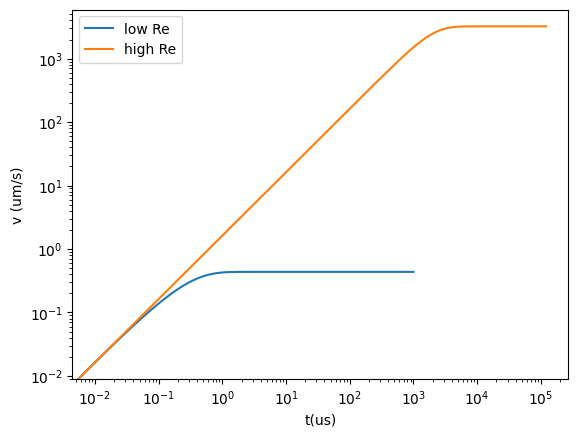

Terminal speed is 4.36e-07 m/s.
It is reached after about 1 microsecond only.
Terminal speed is 0.00323481 m/s.
It is reached after about 1000 microsecond.


In [20]:
# putting everything we learned above into a function for re-use
# also adding a different force, depending on the Reynolds number
def microbead(r0, lowReynolds = True):
    V0 = (4/3) * np.pi * r0**3
    m0 = rho_p * V0
    A0 = np.pi * r0**2
    # net downward force from gravity + buoyancy
    Fg0 = (rho_p - rho_w) * V0 * g
    # Time scale as to be very small for small particles
    if lowReynolds:
        dt = 10e-9       # 10 ns  
    else:
        dt = 1200e-9     # 1200 ns, parameters are much different
    tf = 100000 * dt   # final time
    N = int(np.ceil(tf/dt)) + 1  # ladder problem, so +1

    t = np.linspace(0, tf, N)
    v = np.zeros(N)      # downward velocity (m/s)
    y = np.zeros(N)      # downward position (m)

    # Euler-Cromer to predict path
    for n in range(N-1):
        if lowReynolds:
            F_drag = -6*np.pi*eta*r0 * v[n]  # drag is opposite to velocity direction
        else: # $F = 0.5 \rho C_d A v^2$
            F_drag = -0.5*rho_w*Cd*A0 * v[n]**2  # drag is opposite to velocity direction
        F_net = Fg0 + F_drag      # mass down, drag u    

        # Euler–Cromer update
        v[n+1] = v[n] + (F_net / m0) * dt
        y[n+1] = y[n] + v[n+1] * dt  # Euler-Cromer, use v[n+1] instead of v[n]
        
    return t,y,v  # time, position, speed

# (c) Plot
# --------------------------------------------
t1,y1,v1 = microbead(1e-6, True)
t2,y2,v2 = microbead(1e-6, False)

fig,ax = plt.subplots()
ax.plot(t1/1e-6,v1/1e-6, label="low Re")
ax.plot(t2/1e-6,v2/1e-6, label="high Re") 
ax.set_xlabel("t(us)"); ax.set_ylabel("v (um/s)")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
plt.show() 

print(f"Terminal speed is {v1[-1]:3g} m/s.\nIt is reached after about 1 microsecond only.")
print(f"Terminal speed is {v2[-1]:3g} m/s.\nIt is reached after about 1000 microsecond.")

In [21]:
# (c) Plot for multiple beads
# --------------------------------------------
r_list = np.array([0.5,1,2,3,5,8,10,15,20]) * 1e-6 

r_um_list = []
v_low_term = []
v_high_term = []

print("Check terminal velocity is reached:\n----------------------")
for r0 in r_list:
  t1,y1,v1 = microbead(r0, True)
  t2,y2,v2 = microbead(r0, False)
  # need to make sure terminal velocity is reached
  a = (v2[-1]-v2[-2])/(t2[-1]-t2[-2])
  print(f"{r0:3g} microbead has a={a:6g} N/kg")
  
  r_um = int(r0/1e-6)
  r_um_list.append(r_um)
  v_low_term.append(v1[-1])
  v_high_term.append(v2[-2])

Check terminal velocity is reached:
----------------------
5e-07 microbead has a=     0 N/kg
1e-06 microbead has a=     0 N/kg
2e-06 microbead has a=     0 N/kg
3e-06 microbead has a=     0 N/kg
5e-06 microbead has a=     0 N/kg
8e-06 microbead has a=     0 N/kg
1e-05 microbead has a=     0 N/kg
1.5e-05 microbead has a=     0 N/kg
2e-05 microbead has a=1.01192e-11 N/kg


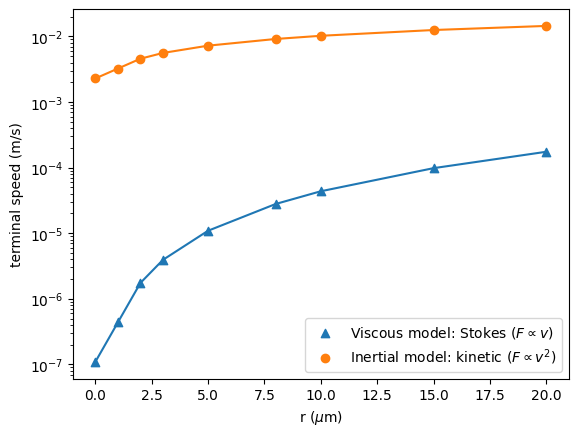

In [22]:
fig,ax = plt.subplots()
ax.scatter(r_um_list,v_low_term, marker="^", label="Viscous model: Stokes ($F\\propto v$)")
ax.plot(r_um_list,v_low_term)
ax.scatter(r_um_list,v_high_term, label="Inertial model: kinetic ($F\\propto v^2$)")  
ax.plot(r_um_list,v_high_term)
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel("terminal speed (m/s)")
ax.legend()
#ax.set_xscale("log")
ax.set_yscale("log")
plt.show() 

The End.